In [1]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load FLAN-T5 Base Model
model_name = "google/flan-t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

print("FLAN-T5 Base Model Downloaded Successfully!")


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

C:\lenovo-ideapad\CUDA_PJT\env\lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Harsh\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 Base Model Downloaded Successfully!


In [4]:
model.save_pretrained("./flan_t5_base_model")
tokenizer.save_pretrained("./flan_t5_base_model")


Configuration saved in ./flan_t5_base_model\config.json
Configuration saved in ./flan_t5_base_model\generation_config.json
Model weights saved in ./flan_t5_base_model\model.safetensors
tokenizer config file saved in ./flan_t5_base_model\tokenizer_config.json
Special tokens file saved in ./flan_t5_base_model\special_tokens_map.json
added tokens file saved in ./flan_t5_base_model\added_tokens.json


('./flan_t5_base_model\\tokenizer_config.json',
 './flan_t5_base_model\\special_tokens_map.json',
 './flan_t5_base_model\\spiece.model',
 './flan_t5_base_model\\added_tokens.json')

## Code to run the locally loaded model

In [14]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

# model_path = "./flan_t5_base_model"
model_path = "./t5_finetuned_emotion/"
tokenizer = T5Tokenizer.from_pretrained(model_path)
model = T5ForConditionalGeneration.from_pretrained(model_path)

print("FLAN-T5 Base Model Loaded from Local Storage!")


FLAN-T5 Base Model Loaded from Local Storage!


In [15]:
import pandas as pd
from string import Template
from pathlib import Path

import warnings
warnings.simplefilter("ignore")

import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

data_path = Path('./emotions.csv')

# **We'll use FLAN-T5-base from Kaggle's Model Hub¶**


In [16]:
# llm = '/kaggle/input/flan-t5/pytorch/base'


# device = "cuda:0" if torch.cuda.is_available() else "cpu"
# model = T5ForConditionalGeneration.from_pretrained(llm).to(device)
# tokenizer = T5Tokenizer.from_pretrained(llm)

The data is formatted as follows. For each prompt (e.g., the question) there are five possible answers labeled [A-F]. Only one of the answers is correct.

In [17]:
test = pd.read_csv('./emotions.csv')
test.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [18]:
df_reduce = test.copy()

df_reduce['label'] = df_reduce['label'].replace(1, 'joy')
df_reduce['label'] = df_reduce['label'].replace(0, 'sadness')
df_reduce['label'] = df_reduce['label'].replace(3, 'anger')
df_reduce['label'] = df_reduce['label'].replace(2, 'love')
df_reduce['label'] = df_reduce['label'].replace(4, 'fear')
df_reduce['label'] = df_reduce['label'].replace(5, 'surprise')

In [19]:
df_reduce.head()

,text,label
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sadness
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sadness
4,i am a kindergarten teacher and i am thoroughl...,fear


In [20]:
df_reduce.label.unique()

array(['fear', 'sadness', 'love', 'joy', 'surprise', 'anger'],
      dtype=object)

# **Creating a preamble template**

How you format your prompt to input to the LLM can make a big difference in the output you get. Here, we try to instruct the LLM to rank all of the options from most likely to least likely.

In [21]:
preamble = \
    'Find the most appropriate sentiment with the letters A, B, C, D, E and F. '

template = Template('$preamble\n\n$prompt\n\nA) $a\nB) $b\nC) $c\nD) $d\nE) $e\nF) $f')

In [22]:
#### ORIGINAL ######


def format_input(df, idx):
    
    prompt = df.loc[idx, 'content']
    a = 'neutral'
    b = 'sadness'
    c = 'fun'
    d = 'worry'
    e = 'love'
    f = 'anger'

    input_text = template.substitute(
        preamble=preamble, prompt=prompt, a=a, b=b, c=c, d=d, e=e, f=f)
    
    return input_text

In [23]:
def format_input(df, idx):
    
    prompt = idx
    a = 'surprise'
    b = 'sadness'
    c = 'joy'
    d = 'fear'
    e = 'love'
    f = 'anger'

    input_text = template.substitute(
        preamble=preamble, prompt=prompt, a=a, b=b, c=c, d=d, e=e, f=f)
    
    return input_text

In [24]:
val=3

In [25]:
print(format_input(df_reduce, "i dont know i feel so lost"))


Find the most appropriate sentiment with the letters A, B, C, D, E and F. 

i dont know i feel so lost

A) surprise
B) sadness
C) joy
D) fear
E) love
F) anger


In [26]:
# inputs = tokenizer(format_input(df_reduce, val), return_tensors="pt").to(device)
# outputs = model.generate(**inputs)
# answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)

# print(answer)

In [33]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Detect GPU

# Load tokenizer and model
from transformers import T5Tokenizer, T5ForConditionalGeneration
model_name = "google/flan-t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)  # Move model to GPU

# Tokenize input and move to the correct device
inputs = tokenizer(format_input(df_reduce, "Oh my god i can not believe it"), return_tensors="pt").to(device)

# Ensure all tensors are on the same device before passing to model.generate()
outputs = model.generate(**inputs)

# Decode output
answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)

print(answer)

['A']


## PUNCTUATIONS NIGGA (not needed tho)

In [69]:
# from transformers import T5Tokenizer, T5ForConditionalGeneration

# # Load FLAN-T5 Model
# model_name = "google/flan-t5-base"
# tokenizer = T5Tokenizer.from_pretrained(model_name)
# model = T5ForConditionalGeneration.from_pretrained(model_name)

# # Function to add punctuation
# def correct_punctuation(text):
#     input_text = f"Fix the punctuation in this sentence: {text}"
#     inputs = tokenizer(input_text, return_tensors="pt").input_ids
#     output = model.generate(inputs)
#     return tokenizer.decode(output[0], skip_special_tokens=True)

# # Example
# transcribed_text = "with the all spark gone we cannot return life to our planet and fate has yielded it's reward a new world to call home we live among it's people now hiding in plain sight but watching over them"
# punctuated_text = correct_punctuation(transcribed_text)
# print("Punctuated Text:", punctuated_text)


📊 ASR Model Performance Metrics
🔹 Word Error Rate (WER): 31.71%
🔹 Character Error Rate (CER): 17.18%


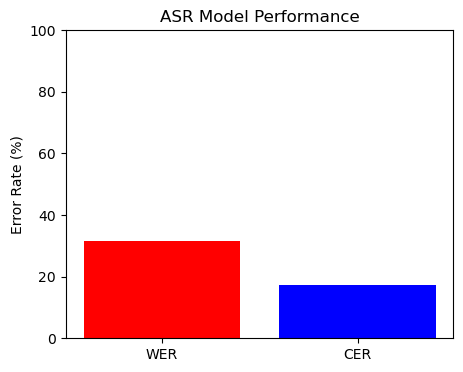

In [3]:
from jiwer import wer, cer
import matplotlib.pyplot as plt

# Reference text (Ground truth)
reference_text = "With the all-spark gone, we cannot return life to our planet and fate has yielded it's reward. A new world to call home. We live among it's people now, hiding in plain sight but watching over them in secret, waiting, protecting"

# ASR output (from Vosk or another ASR model)
asr_output = "with the all spark gone we cannot return life to our planet and fate has yielded it's reward a new world to call home we live among it's people now hiding in plain sight but watching over them"

# Compute WER & CER
wer_score = wer(reference_text, asr_output) * 100  # Convert to percentage
cer_score = cer(reference_text, asr_output) * 100  # Convert to percentage

# Print results
print(f"📊 ASR Model Performance Metrics")
print(f"🔹 Word Error Rate (WER): {wer_score:.2f}%")
print(f"🔹 Character Error Rate (CER): {cer_score:.2f}%")

# Generate Bar Chart for PPT
metrics = ["WER", "CER"]
values = [wer_score, cer_score]

plt.figure(figsize=(5,4))
plt.bar(metrics, values, color=["red", "blue"])
plt.ylabel("Error Rate (%)")
plt.title("ASR Model Performance")
plt.ylim(0, 100)
plt.savefig("asr_performance.png")  # Save for PPT
plt.show()


In [4]:
from jiwer import wer, cer, mer, wil, wip, compute_measures

# Reference (Actual Speech)
reference_text = "Hello, how are you doing today?"

# ASR Output (Transcribed Speech)
asr_output = "Hello how are you doing today"

# Compute Metrics
wer_score = wer(reference_text, asr_output) * 100
cer_score = cer(reference_text, asr_output) * 100
mer_score = mer(reference_text, asr_output) * 100
wil_score = wil(reference_text, asr_output) * 100
wip_score = wip(reference_text, asr_output) * 100

# Compute SER (Sentence Error Rate) manually
def compute_ser(ref, hyp):
    ref_sentences = ref.split(".")
    hyp_sentences = hyp.split(".")
    incorrect_sentences = sum([1 for r, h in zip(ref_sentences, hyp_sentences) if r.strip() != h.strip()])
    return (incorrect_sentences / len(ref_sentences)) * 100

ser_score = compute_ser(reference_text, asr_output)

# Print Results
print(f"📊 ASR Model Performance Metrics:")
print(f"🔹 Word Error Rate (WER): {wer_score:.2f}%")
print(f"🔹 Character Error Rate (CER): {cer_score:.2f}%")
print(f"🔹 Match Error Rate (MER): {mer_score:.2f}%")
print(f"🔹 Word Information Lost (WIL): {wil_score:.2f}%")
print(f"🔹 Word Information Preserved (WIP): {wip_score:.2f}%")
print(f"🔹 Sentence Error Rate (SER): {ser_score:.2f}%")


📊 ASR Model Performance Metrics:
🔹 Word Error Rate (WER): 33.33%
🔹 Character Error Rate (CER): 6.45%
🔹 Match Error Rate (MER): 33.33%
🔹 Word Information Lost (WIL): 55.56%
🔹 Word Information Preserved (WIP): 44.44%
🔹 Sentence Error Rate (SER): 100.00%


(0.0, 100.0)

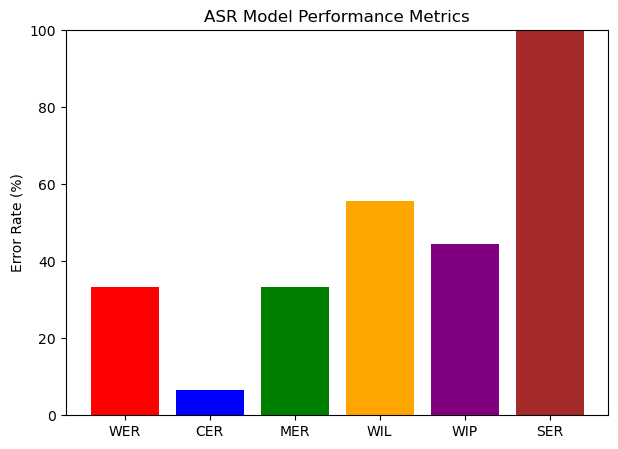

In [5]:
import matplotlib.pyplot as plt

# Metrics & Values
metrics = ["WER", "CER", "MER", "WIL", "WIP", "SER"]
values = [wer_score, cer_score, mer_score, wil_score, wip_score, ser_score]

# Plot Bar Chart
plt.figure(figsize=(7,5))
plt.bar(metrics, values, color=["red", "blue", "green", "orange", "purple", "brown"])
plt.ylabel("Error Rate (%)")
plt.title("ASR Model Performance Metrics")
plt.ylim(0, 100)
